In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import scipy.stats as stats
import arch

import pricing as P
import utils as U

### **Value at Risk (VaR) и Expected Shortfall (ES)**

In [2]:
def extract_data(fname):
    df = pd.read_csv(fname, parse_dates=["DATE"])
    df = df.set_index("DATE")
    df = df.sort_index()
    return df


def extract_cashflow_curve(fname):
    df = pd.read_csv(fname, parse_dates=["date"])
    df["ofz_id"] = df["secid"].map(P.OFZ_ISIN_TO_ID)
    return df


def extract_params(fname):
    df = pd.read_csv(fname)
    df = df.set_index("factor")
    return df


df_md = extract_data("data/data_clean.csv")
df_rf = extract_data("risk_factors_output/risk_factors.csv")

df_cf = extract_cashflow_curve("data/ofz_cashflows.csv")
df_params = extract_params("model_params.csv")

stocks_pca = {
    "pcs": extract_data("risk_factors_output/stock_pcs.csv")
}

ols_params = P.equity_factor_fit(stocks_pca, df_rf)


stock_columns = [
    f"STK_{ticker}" for ticker in P.STOCK_TICKERS
]

In [ ]:
def run_dist_simulation(df_params, factor, horizon, series):
    """
    Запустить симуляцию из нормального / t-распределения
    для риск-фактора
    """
    params_all = df_params.loc[factor].to_dict()
    dist = params_all["best_dist"]

    if dist == "normal":
        loc = params_all["loc"]
        scale = params_all["scale"]
        return stats.norm.rvs(loc, scale, size=horizon)

    if dist == "t":
        df = params_all["df"]
        loc = params_all["loc"]
        scale = params_all["scale"]
        return stats.t.rvs(df, loc, scale, size=horizon)

    raise ValueError(f"Unsupported dist: {dist}")


def run_garch_simulation(df_params, factor, horizon, series):
    """
    Запустить симуляцию GARCH-модели для риск-фактора
    """
    params_all = df_params.loc[factor].to_dict()
    dist = params_all["best_dist"]

    model = arch.arch_model(series, vol="GARCH", p=1, q=1, dist=dist)
    res = model.fit(disp="off")

    sim = res.model.simulate(
        res.params, nobs=horizon, burn=0, initial_value=res.conditional_volatility[-1] 
    )
    return sim["data"]


def run_simulation(df_params, factor, horizon, series):
    """
    Запустить симуляцию для риск-фактора в соответствии с параметрами
    """
    params_all = df_params.loc[factor].to_dict()
    model_type = params_all["model_type"]

    if model_type == "distribution":
        return run_dist_simulation(df_params, factor, horizon, series)
    
    if model_type == "GARCH":
        return run_garch_simulation(df_params, factor, horizon, series)
    
    raise ValueError(f"Unsupported model_type: {model_type}")


def simulate_risk_factors(
    df_market, df_params, start_date, end_date
):
    """
    Симулировать доходности риск-факторов
    """
    df_market = df_market.copy()
    result_dict = {}

    index = pd.date_range(start_date, end_date, freq="B")
    horizon = index.size

    df_returns = U.prices_to_returns(df_market, columns=U.RF_PRICES)
    df_returns = df_returns.rename(columns=U.RF_PRICES_TO_RETURNS)
    df_returns = df_returns.loc[:start_date]

    for risk_factor in df_params.index:
        series = df_market.loc[:, risk_factor]

        result_dict[risk_factor] = run_simulation(
            df_params, risk_factor, horizon, series
    )
    
    df_new_returns = pd.DataFrame(data=result_dict, index=index)
    df_new_returns = df_new_returns.rename(columns=U.RF_RETURNS_TO_PRICES)

    base_prices = df_market.loc[start_date, U.RF_PRICES]
    df_new_prices = U.returns_to_prices(df_new_returns, base_prices, columns=U.RF_PRICES)
    
    return df_new_prices

In [ ]:
def price_samples(
        n, df_params, df_market, start_date, end_date, ols_params
    ):
        result = []

        for _ in range(n):
            df = simulate_risk_factors(df_params, df_market, start_date, end_date)
            
            df_md = df_market.copy()
            df_md.loc[start_date:end_date, U.RF_PRICES] = df[U.RF_PRICES]

            df_stats = P.backtest_portfolio(
                P.DEFAULT_PORTFOLIO, df_md, start=start_date, end=end_date
            )

            final_price = df_stats.loc[end_date, 'value']
            result.append(final_price)
        
        return result

In [46]:
start_date = "2025-12-01"
end_date = "2025-12-02"

prices = price_samples(
    10_000, df_params, df_md, start_date=start_date, end_date=end_date, 
    ols_params=ols_params
)

In [43]:
def get_portfolio_price(date, df_md):
    df = P.backtest_portfolio(
        P.DEFAULT_PORTFOLIO, df_md, start=date, end=date
    )
    return df.loc[date, "value"]

In [48]:
prices = np.array(prices)

var = np.quantile(prices, q=0.01)
es = prices[prices < np.quantile(prices, 0.025)].mean()

start_price = get_portfolio_price(start_date, df_md)

print(f"{es / start_price:.3f}")
print(f"{var / start_price:.3f}")

0.766
0.768


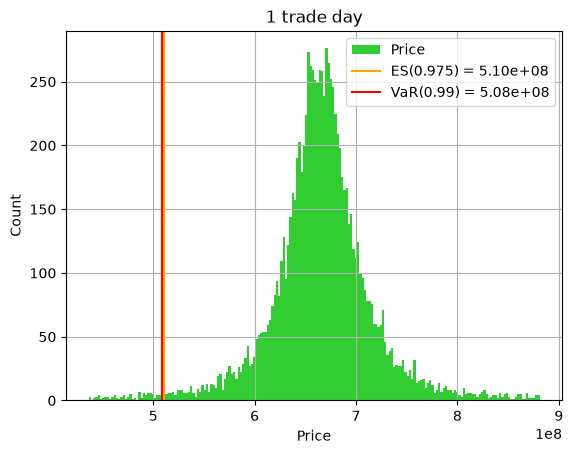

In [34]:
plt.hist(prices, bins=200, color='limegreen', label="Price")
plt.grid()

plt.axvline(x=es, color='orange', label=f"ES(0.975) = {es:.2e}")
plt.axvline(x=var, color='red', label=f"VaR(0.99) = {var:.2e}")

plt.xlabel("Price")
plt.ylabel("Count")

plt.title("1 trade day")

plt.legend()
plt.savefig("plots/prices-day1.png")
plt.show()

In [35]:
start_date = "2025-12-01" # базовая дата
end_date = "2025-12-10"

prices = price_samples(
    10_000, df_params, df_md, start_date=start_date, end_date=end_date, 
    ols_params=ols_params
)

In [40]:
prices = np.array(prices)

var = np.quantile(prices, q=0.01)
es = prices[prices < np.quantile(prices, 0.025)].mean()

start_price = get_portfolio_price(start_date, df_md)

print(f"{es / start_price:.3f}")
print(f"{var / start_price:.3f}")

0.651
0.648


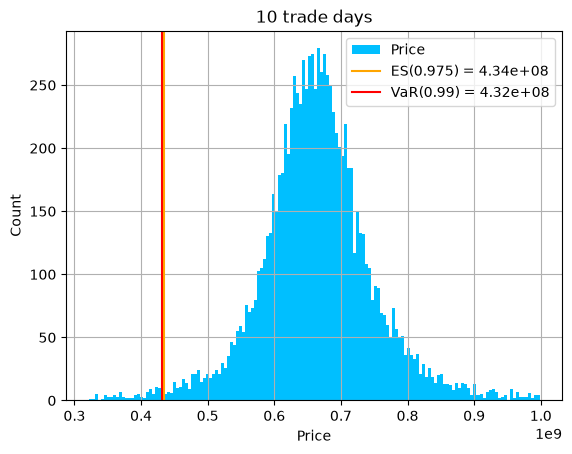

In [39]:
plt.hist(prices, bins=150, color='deepskyblue', label="Price")
plt.grid()

plt.axvline(x=es, color='orange', label=f"ES(0.975) = {es:.2e}")
plt.axvline(x=var, color='red', label=f"VaR(0.99) = {var:.2e}")

plt.xlabel("Price")
plt.ylabel("Count")

plt.title("10 trade days")

plt.legend()
plt.savefig("plots/prices-days10.png")
plt.show()